In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
draft_url = "https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv"
draft = pd.read_csv(draft_url)

In [3]:
player_stats_url = "https://github.com/nflverse/nflverse-data/releases/download/player_stats/player_stats.csv"
player_stats = pd.read_csv(player_stats_url)

In [4]:
contracts_url = "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz"
contracts = pd.read_csv(contracts_url)

In [39]:
contracts.columns

Index(['player', 'position', 'team', 'is_active', 'year_signed', 'years',
       'value', 'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value',
       'inflated_apy', 'inflated_guaranteed', 'player_page', 'otc_id',
       'date_of_birth', 'height', 'weight', 'college', 'draft_year',
       'draft_round', 'draft_overall', 'draft_team', 'season_history'],
      dtype='object')

In [40]:
contracts.head()

,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,...,otc_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,season_history
0,Aaron Rodgers,QB,Packers,True,2022,5.0,150815000,50271667,150665000,0.241,...,1085,NaN,"6'2""",225.0,California,2005.0,1.0,24.0,Packers,NaN
1,Josh Allen,QB,Bills,True,2021,6.0,258000000,43000000,150000000,0.236,...,6892,NaN,"6'5""",233.0,Wyoming,2018.0,1.0,7.0,Bills,NaN
2,Patrick Mahomes,QB,Chiefs,True,2020,10.0,450000000,45000000,141000000,0.227,...,5594,NaN,"6'2""",225.0,Texas Tech,2017.0,1.0,10.0,Chiefs,NaN
3,Deshaun Watson,QB,Browns,True,2022,5.0,230000000,46000000,230000000,0.221,...,5596,NaN,"6'2""",221.0,Clemson,2017.0,1.0,12.0,Texans,NaN
4,Dak Prescott,QB,Cowboys,True,2021,4.0,160000000,40000000,126000000,0.219,...,4848,NaN,"6'2""",226.0,Mississippi State,2016.0,4.0,135.0,Cowboys,NaN


In [54]:
draft = draft[(draft["season"] >= 2000) & (draft["season"] <= 2020)]
draft = draft[draft['w_av'].notna()]

position_order = ['DB', 'WR', 'LB', 'DE', 'DT', 'RB', 'T', 'TE', 'G', 'QB', 'CB', 'C', 'S', 'OLB', 'FB',
                'K', 'P', 'ILB', 'OL', 'NT', 'LS', 'DL']

expected = pd.DataFrame(draft.groupby("pick")["w_av"].mean().reset_index().rename(columns={"w_av": "expected_w_av"}))

draft = draft.merge(expected, on='pick')

draft['ev_delta'] = draft['w_av'] - draft['expected_w_av']
draft['ev_ratio'] = draft['w_av'] / draft['expected_w_av']

expected = expected.set_index('pick')

pos_counts = pd.DataFrame(draft['position'].value_counts())
pos_counts = pos_counts.reindex(position_order)

pos_avg_dr_av = pd.DataFrame(draft.groupby('position')['dr_av'].mean())
pos_avg_dr_av = pos_avg_dr_av.reindex(position_order)

pos_w_av = pd.DataFrame(draft.groupby('position')['w_av'].mean())
pos_w_av = pos_w_av.reindex(position_order)

pos_ev_delta = pd.DataFrame(draft.groupby('position')['ev_delta'].mean())
pos_ev_delta = pos_ev_delta.reindex(position_order)

pos_ratio = pd.DataFrame(draft.groupby('position')['ev_ratio'].mean())
pos_ratio = pos_ratio.reindex(position_order)

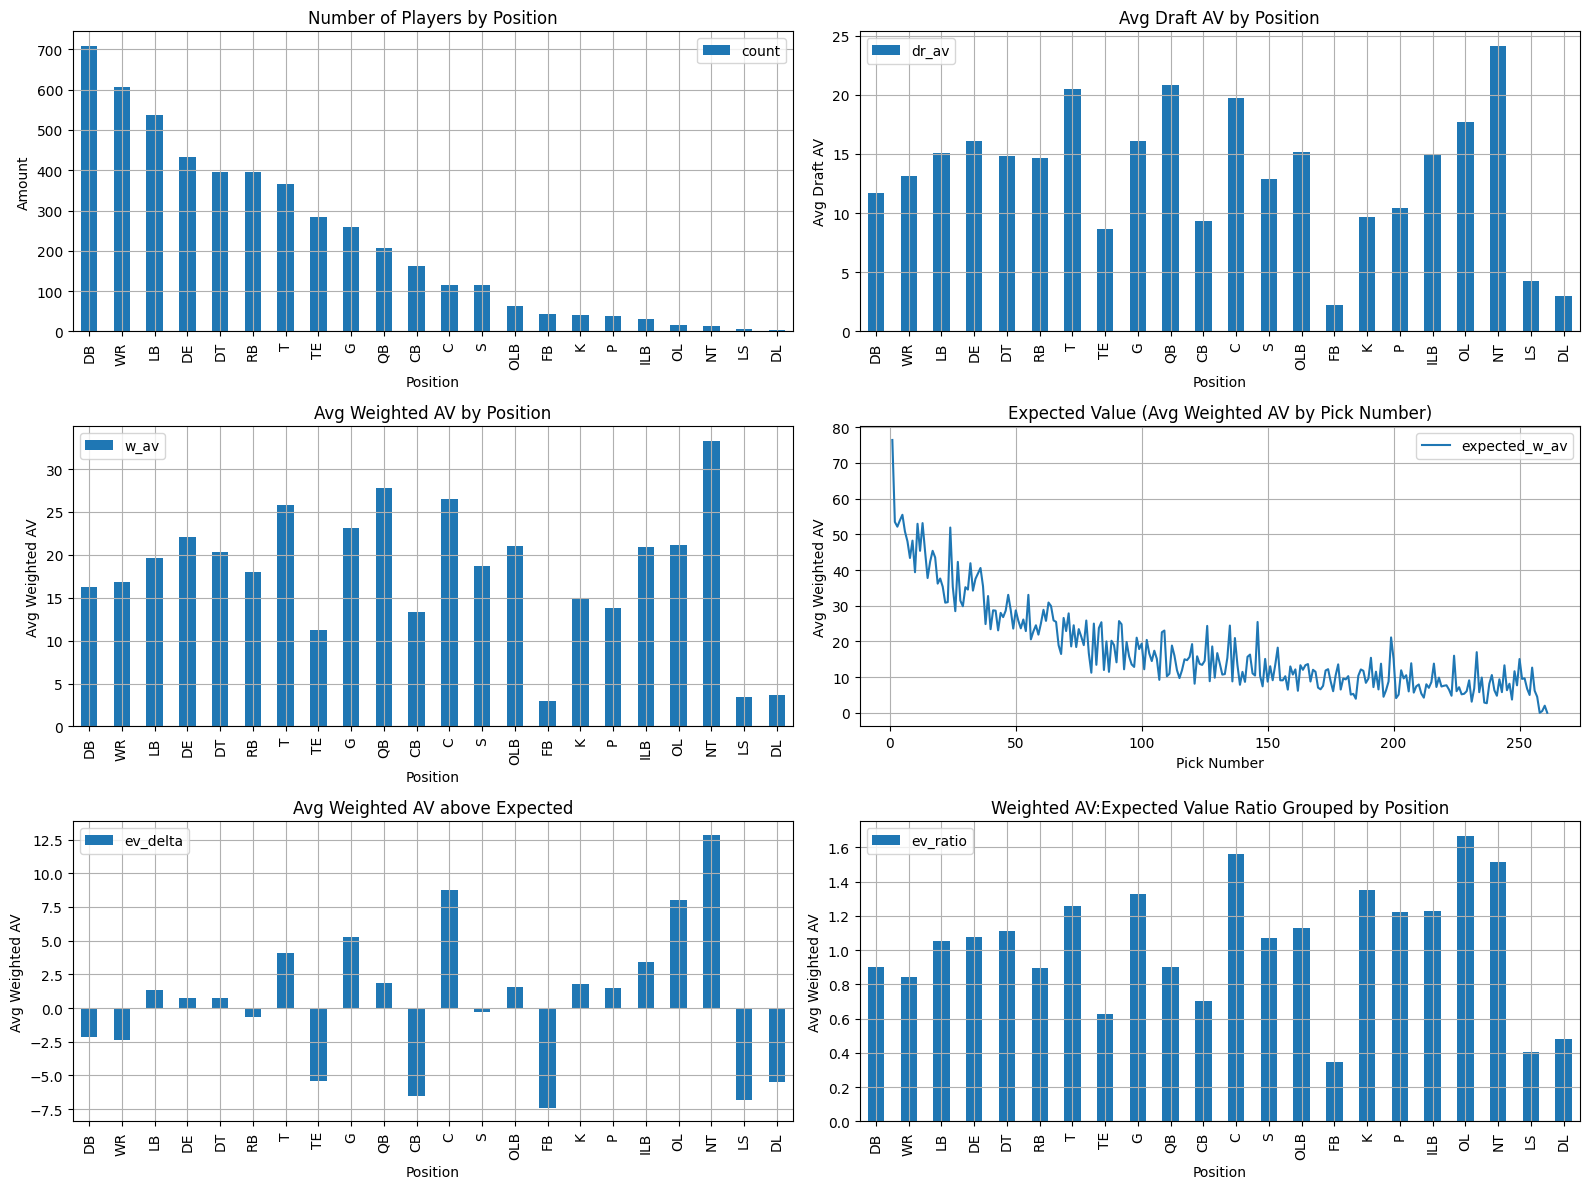

In [55]:

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

pos_counts.plot.bar(
    ax=axes[0, 0],
    title='Number of Players by Position',
    xlabel='Position',
    ylabel='Amount',
    grid=True,
)

pos_avg_dr_av.plot.bar(
    ax=axes[0, 1],
    title='Avg Draft AV by Position',
    xlabel='Position',
    ylabel='Avg Draft AV',
    grid=True,
)

pos_w_av.plot.bar(
    ax=axes[1, 0],
    title='Avg Weighted AV by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

expected.plot.line(
    ax=axes[1, 1],
    title='Expected Value (Avg Weighted AV by Pick Number)',
    xlabel='Pick Number',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ev_delta.plot.bar(
    ax=axes[2, 0],
    title='Avg Weighted AV above Expected',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ratio.plot.bar(
    ax=axes[2, 1],
    title='Weighted AV:Expected Value Ratio Grouped by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.tight_layout()
plt.show()

In [56]:
draft.columns

Index(['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks', 'expected_w_av', 'ev_delta', 'ev_ratio'],
      dtype='str')

In [57]:
draft['pfr_player_name']

0         Courtney Brown
1        LaVar Arrington
2          Chris Samuels
3          Peter Warrick
4            Jamal Lewis
              ...       
4831    Stephen Sullivan
4832     Tyrie Cleveland
4833         Kyle Hinton
4834       Derrek Tuszka
4835         Tae Crowder
Name: pfr_player_name, Length: 4836, dtype: str

In [58]:
draft['pfr_player_name'] = draft['pfr_player_name'].str.strip().str.lower()
contracts['player'] = contracts['player'].str.strip().str.lower()

In [59]:
overlap = set(draft['pfr_player_name']) & set(contracts['player'])
len(overlap)

3084